In [1]:
import os
import sys
import MDAnalysis as mda
import numpy as np
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import pandas as pd
import nglview as nv

path = os.path.join('..', '.')
if path not in sys.path:
    sys.path.append(os.path.abspath(path))

from src.protein_graph import pncaGraph

## Get coords of centre of masses of PncA residues

In [2]:
pnca = pncaGraph(
    pdb='../pdb/3PL1-PZA.pdb',
    lig_resname='PZA', 
    self_loops=False,
    cutoff_distance=12)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:348: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using MDAnalysis.topology.guessers.
  warnings.warn(wmsg)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: 
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


In [3]:
res_coords = pnca.nodes.center_of_mass(compound='residues')

## K-means on residue coords

In [4]:
K = 10
region = KMeans(n_clusters=K, random_state=0, n_init="auto").fit_predict(res_coords)

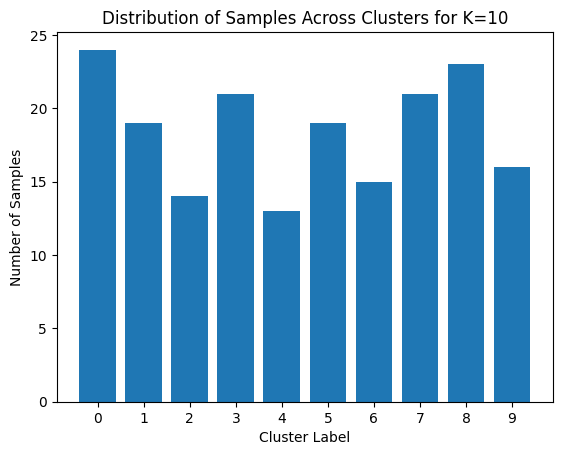

In [5]:
# plot distribution of samples across clusters

counts = np.unique(region, return_counts=True)

plt.bar(counts[0], counts[1])
plt.xticks(counts[0])
plt.xlabel('Cluster Label')
plt.ylabel('Number of Samples')
plt.title(f'Distribution of Samples Across Clusters for K={K}')
plt.show()

## Assign mutations from dataset to respective clusters

In [6]:
pnca_paper_dataset = pd.read_csv('../data/ds-traintest-phen.csv')

def split_mutation(row):
    return pd.Series([row.MUTATION[0], int(row.MUTATION[1:-1]), row.MUTATION[-1]])

pnca_paper_dataset[['REF','AMINO_ACID','ALT']] = pnca_paper_dataset.apply(split_mutation,axis=1)

pnca_paper_dataset.head(10)

,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT
0,A102V,S,A,102,V
1,A134D,S,A,134,D
2,A134P,R,A,134,P
3,A134S,S,A,134,S
4,A134V,R,A,134,V
5,A143D,R,A,143,D
6,A143G,R,A,143,G
7,A143V,S,A,143,V
8,A146E,R,A,146,E
9,A146S,R,A,146,S


In [7]:
res_to_region = {pos: int(region[pos-1]) for pos in range(1, res_coords.shape[0]+1)}

pnca_paper_dataset['cluster'] = pnca_paper_dataset['AMINO_ACID'].map(res_to_region)

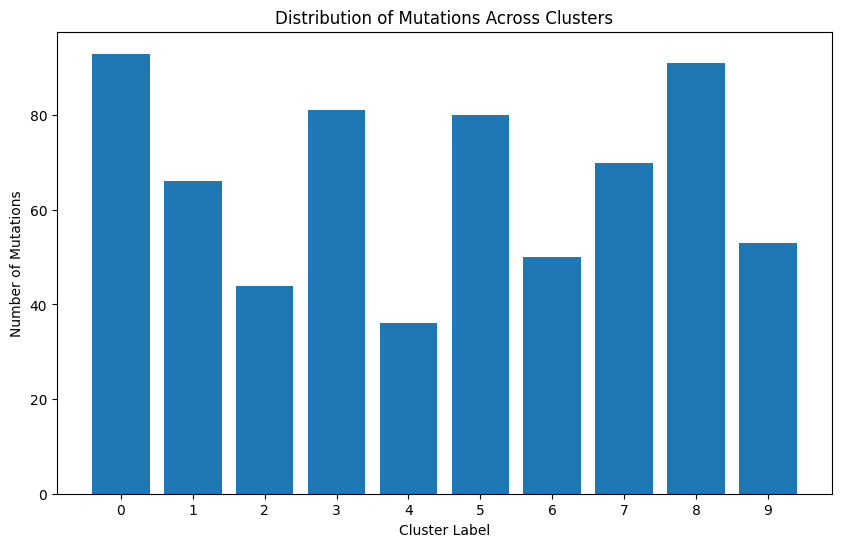

In [8]:
cluster_counts = pnca_paper_dataset['cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster Label')
plt.ylabel('Number of Mutations')
plt.title('Distribution of Mutations Across Clusters')
plt.xticks(range(K))
plt.show()

## Inspect clusters

In [9]:
# dict with clusters as keys and residues as values 
region_to_res = {}
for res, region in res_to_region.items():
    region_to_res.setdefault(region, []).append(res)

In [10]:
col_dict = {
    0: "red",
    1: "blue",
    2: "green",
    3: "yellow",
    4: "orange",
    5: "purple",
    6: "cyan",
    7: "magenta",
    8: "lime",
    9: "pink"
}

In [20]:
# rep = [{"type": "hyperball", "params": {
#     "sele": f"({', '.join(map(str, region_to_res[cluster]))})",
#     "color" : col_dict[cluster]}}
#        for cluster in range(K)]

rep = [{"type": "spacefill", "params": {
    "sele": f"({', '.join(map(str, region_to_res[cluster]))}) and .CA",
    "color" : col_dict[cluster]}}
       for cluster in range(K)]

rep.append({"type": "licorice", "params": {
    "sele": "not protein",
    # "color" : "black"
    }})

In [21]:
view = nv.show_file("../pdb/3PL1-PZA.pdb")

view.set_representations(rep)

view

NGLWidget()

## Assign clusters to train/test

In [50]:
def split_clusters_greedy(cluster_ids, test_frac=0.3, seed=0):
    """
    cluster_ids: array-like of cluster id per sample
    returns: boolean mask test=True/train=False
    """
    rng = np.random.default_rng(seed)

    # count samples per cluster
    unique, counts = np.unique(cluster_ids, return_counts=True)
    clusters = list(zip(unique, counts))

    rng.shuffle(clusters)

    total = counts.sum()
    target = total * test_frac

    test_clusters = set()
    running = 0

    for cid, size in clusters:
        if running >= target:
            break
        test_clusters.add(cid)
        running += size

    return np.array([cid in test_clusters for cid in cluster_ids])

In [51]:
test_mask = split_clusters_greedy(pnca_paper_dataset.cluster.values)
train_df = pnca_paper_dataset[~test_mask]
test_df = pnca_paper_dataset[test_mask]

test_df

,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT,cluster
18,A165D,R,A,165,D,4
19,A170S,R,A,170,S,4
20,A170V,R,A,170,V,4
21,A171E,R,A,171,E,4
22,A171T,R,A,171,T,4
...,...,...,...,...,...,...
646,W68R,R,W,68,R,6
656,Y64N,S,Y,64,N,6
657,Y95C,S,Y,95,C,7
658,Y95H,S,Y,95,H,7


In [55]:
print('Train clusters and counts:')
print(train_df.cluster.value_counts().sort_values())
print('\nTest clusters and counts:')
print(test_df.cluster.value_counts().sort_values())

Train clusters and counts:
cluster
9    53
1    66
5    80
3    81
8    91
0    93
Name: count, dtype: int64

Test clusters and counts:
cluster
4    36
2    44
6    50
7    70
Name: count, dtype: int64


## Vis train/test clusters

In [58]:
train_col = 'red'
test_col = 'cyan'

rep = [{"type": "spacefill", "params": {
    "sele": f"({', '.join(map(str, region_to_res[cluster]))}) and .CA",
    "color" : train_col if cluster in train_df.cluster.values else test_col}}
       for cluster in range(K)]

rep.append({"type": "licorice", "params": {
    "sele": "not protein",
    # "color" : "black"
    }})

In [59]:
view = nv.show_file("../pdb/3PL1-PZA.pdb")

view.set_representations(rep)

view

NGLWidget()